# **Metodologia**
A metodologia adotada neste trabalho foi estruturada em duas etapas principais, com o objetivo de estimar e desagregar o déficit habitacional para níveis espaciais mais detalhados.

Na primeira etapa, foi desenvolvido um modelo de aprendizado supervisionado utilizando o algoritmo Random Forest para estimar o déficit habitacional total nas Áreas de Ponderação (APs). Esse modelo foi treinado com base em variáveis socioeconômicas, estruturais e habitacionais, permitindo capturar relações não lineares e interações complexas entre os atributos.

Na segunda etapa, foi implementado um processo de desagregação espacial baseado em escores de propensão. Nesse processo, o modelo treinado foi aplicado aos setores censitários, gerando valores preditos que representam a propensão relativa de cada setor em relação ao déficit habitacional.

Esses valores foram utilizados como pesos proporcionais para redistribuir o déficit total das Áreas de Ponderação entre os setores censitários pertencentes a cada área. Esse procedimento garante consistência agregada, ou seja, a soma dos valores desagregados corresponde exatamente ao total observado ou estimado na AP.


In [ ]:
import pandas as pd

# 1. Carregar os arquivos
df_sp_ap = pd.read_excel('BD_SP_DEFICIT.xlsx')
df_sp_sc = pd.read_excel('BANCO_SP_setorcensitario.xlsx')

Nesta etapa, realiza-se a verificação da integridade dos dados após a unificação das bases da capital e do interior. Essa validação é essencial para garantir que o processo de concatenação não introduziu inconsistências, perdas de registros ou duplicações indesejadas.

Além disso, a inspeção inicial das bases permite compreender a dimensão dos dados e validar se a estrutura está adequada para as etapas posteriores de modelagem.

In [ ]:
# 3. Verificar o resultado (AREA DE PODERACAO)
print(f"BANCO DE DADOS DE AREA DE PONDERACAO")
print(f"Total Unificado: {len(df_sp_ap)}")

# Visualizar as primeiras linhas
df_sp_ap.head()

BANCO DE DADOS DE AREA DE PONDERACAO
Total Unificado: 1878


,AREA_POND,Cod_UF,Nome_da_UF,Cod_meso,Nome_da_meso,Cod_micro,Nome_da_micro,Cod_RM,Nome_da_RM,Cod_municipio,...,Soma_V206,Soma_V207,Soma_soma_V202eV203,Soma_soma_V204eV205,Soma_soma_V206eV207,DOMICILIOS_PRECARIOS,COABITACAO,ONUS_EXCESSIVO,ADENSAMENTO,DEFICIT_TOTAL
0,3500105003001,35,São Paulo,3508,Presidente Prudente,35035,Adamantina,0,Municípios não pertencentes a estrutura de RM,3500105,...,0,0,3991,17,0,0,164,210,20,394
1,3500105003002,35,São Paulo,3508,Presidente Prudente,35035,Adamantina,0,Municípios não pertencentes a estrutura de RM,3500105,...,0,0,6487,99,0,53,403,226,23,705
2,3500204001001,35,São Paulo,3501,São José do Rio Preto,35004,São José do Rio Preto,0,Municípios não pertencentes a estrutura de RM,3500204,...,0,0,1044,37,0,0,67,40,6,112
3,3500303003001,35,São Paulo,3507,Campinas,35029,Pirassununga,0,Municípios não pertencentes a estrutura de RM,3500303,...,2,2,8644,127,4,34,637,524,104,1300
4,3500402001001,35,São Paulo,3507,Campinas,35030,São João da Boa Vista,0,Municípios não pertencentes a estrutura de RM,3500402,...,0,10,2042,202,10,8,124,96,17,246


In [ ]:
# 3. Verificar o resultado (SETORES CENSITARIOS)
print(f"BANCO DE DADOS DE SETORES CENSITARIOS")
print(f"Total Unificado: {len(df_sp_sc)}")

# Visualizar as primeiras linhas
df_sp_sc.head()

BANCO DE DADOS DE SETORES CENSITARIOS
Total Unificado: 60483


,Cod_setor,Cod_Grandes_Regiões,Nome_Grande_Regiao,Cod_UF,Nome_da_UF,Cod_meso,Nome_da_meso,Cod_micro,Nome_da_micro,Cod_RM,...,Domicílios particulares permanentes que não tinham banheiro ou sanitário – Existe lixo acumulado nos logradouros,Domicílios particulares permanentes com moradia adequada – Existe identificação do logradouro,Domicílios particulares permanentes com moradia adequada – Não existe identificação do logradouro,Domicílios particulares permanentes com moradia semi-adequada – Existe identificação do logradouro,Domicílios particulares permanentes com moradia semi-adequada – Não existe identificação do logradouro,Domicílios particulares permanentes com moradia inadequada – Existe identificação do logradouro,Domicílios particulares permanentes com moradia inadequada – Não existe identificação do logradouro,soma_V202eV203,soma_V204eV205,soma_V206eV207
0,355030801000001,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,228,5,33,0,0,0,233,33,0
1,355030801000002,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,306,0,0,0,0,0,306,0,0
2,355030801000003,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,184,0,5,0,0,0,184,5,0
3,355030801000004,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,181,0,0,0,0,0,181,0,0
4,355030801000005,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,239,0,1,0,0,0,239,1,0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [ ]:
COL_AP_AP = "AREA_POND"          # nome da coluna de AP no banco de AP
COL_AP_SC = "Área de Ponderação"       # nome da coluna de AP no banco de SC
COL_SC = "Cod_setor"       # código do setor censitário
#COL_TARGET = "DEFICIT_TOTAL"


In [ ]:
SAIDAS = [
    "DOMICILIOS_PRECARIOS",
    "COABITACAO",
    "ONUS_EXCESSIVO",
    "ADENSAMENTO",
    "DEFICIT_TOTAL"
]

In [ ]:
# Criamos a lista de FEATURES selecionando pelo índice das colunas
#(entradas do modelo)
# O intervalo [11:79] pega da coluna 12 até a 79
FEATURES = df_sp_ap.columns[11:79].tolist()

In [ ]:
print(FEATURES[0], "até", FEATURES[-1])

Soma_V002.x até Soma_soma_V206eV207


Nesta etapa, é realizada a construção do modelo de aprendizado de máquina. Inicialmente, são tratadas observações com valores faltantes na variável alvo, garantindo a qualidade do treinamento.

Em seguida, os dados são divididos em conjuntos de treino e teste, permitindo avaliar a capacidade de generalização do modelo. O algoritmo Random Forest é utilizado devido à sua robustez, capacidade de lidar com variáveis correlacionadas e menor sensibilidade a overfitting.

In [ ]:
#ANOTACOES
# VERIFICAR (coluna 12 ate 79)
#dicionário das variáveis: https://docs.google.com/spreadsheets/d/1Gc1sElD3oJmbiD0C95pO2k-Q58KzVHpC/edit?usp=drive_link&ouid=108259536837041896668&rtpof=true&sd=true
# banco de dados ap
# https://docs.google.com/spreadsheets/d/1KNx4c1HX7uTK1IP_eCbtQBKABNk_ajr5/edit?gid=804364008#gid=804364008
# banco de dados SC
# https://docs.google.com/spreadsheets/d/1gFnI1BTN1n0EDUrpEXExweGm2v18bq4j/edit?gid=1629106962#gid=1629106962


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# remover faltantes
df_ap_modelo = df_sp_ap.dropna(subset=["DEFICIT_TOTAL"]).copy()

# Definição de X (Features) e y (Target)
X = df_ap_modelo[FEATURES]
y = df_ap_modelo["DEFICIT_TOTAL"]

# divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# modelo
# Configuração do modelo Random Forest
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# treino
modelo_rf.fit(X_train, y_train)

# previsão
y_pred = modelo_rf.predict(X_test)

# métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n MÉTRICAS – DEFICIT_TOTAL - RANDOM FOREST  (AP)")
print(f"R²  : {r2:.3f}")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


 MÉTRICAS – DEFICIT_TOTAL - RANDOM FOREST  (AP)
R²  : 0.952
MAE : 97.609
RMSE: 142.696


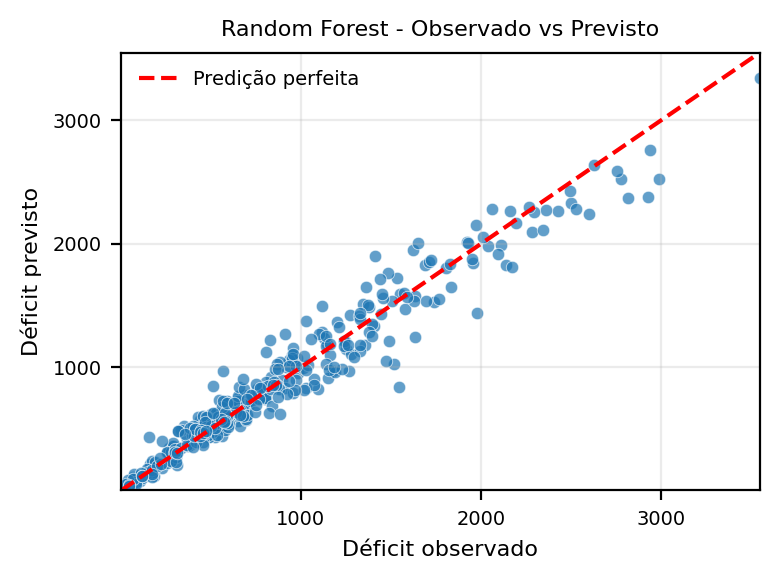

In [ ]:
# ==========================================
# OBSERVADO VS PREVISTO
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4, 3), dpi=200)

plt.scatter(
    y_test,
    y_pred,
    s=20,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.3
)

# Limites iguais para os eixos
lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())

# Linha ideal
plt.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle='--',
    linewidth=1.5,
    color='red',
    label='Predição perfeita'
)

plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)

plt.xlabel('Déficit observado', fontsize=8)
plt.ylabel('Déficit previsto', fontsize=8)
plt.title("Random Forest - Observado vs Previsto", fontsize=8)

# Diminui os números dos eixos
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.grid(True, alpha=0.25)

# Diminui a legenda
plt.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.show()

# **Validacao cruzada**

In [ ]:
# =====================================================
# VALIDAÇÃO CRUZADA (CROSS VALIDATION)
# =====================================================

from sklearn.model_selection import cross_val_score

scores_r2 = cross_val_score(
    modelo_rf,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

scores_mae = -cross_val_score(
    modelo_rf,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("\n===== VALIDAÇÃO CRUZADA =====")

print("R² por Fold:")
print(scores_r2)

print(f"R² Médio: {scores_r2.mean():.4f}")
print(f"R² Desvio: {scores_r2.std():.4f}")

print(f"MAE Médio: {scores_mae.mean():.4f}")
print(f"MAE Desvio: {scores_mae.std():.4f}")


===== VALIDAÇÃO CRUZADA =====
R² por Fold:
[0.92945357 0.94319551 0.94950391 0.87677297 0.91821408]
R² Médio: 0.9234
R² Desvio: 0.0257
MAE Médio: 104.2461
MAE Desvio: 37.5037


# **SHAP Values**

In [ ]:
!pip install shap


Calculando SHAP...


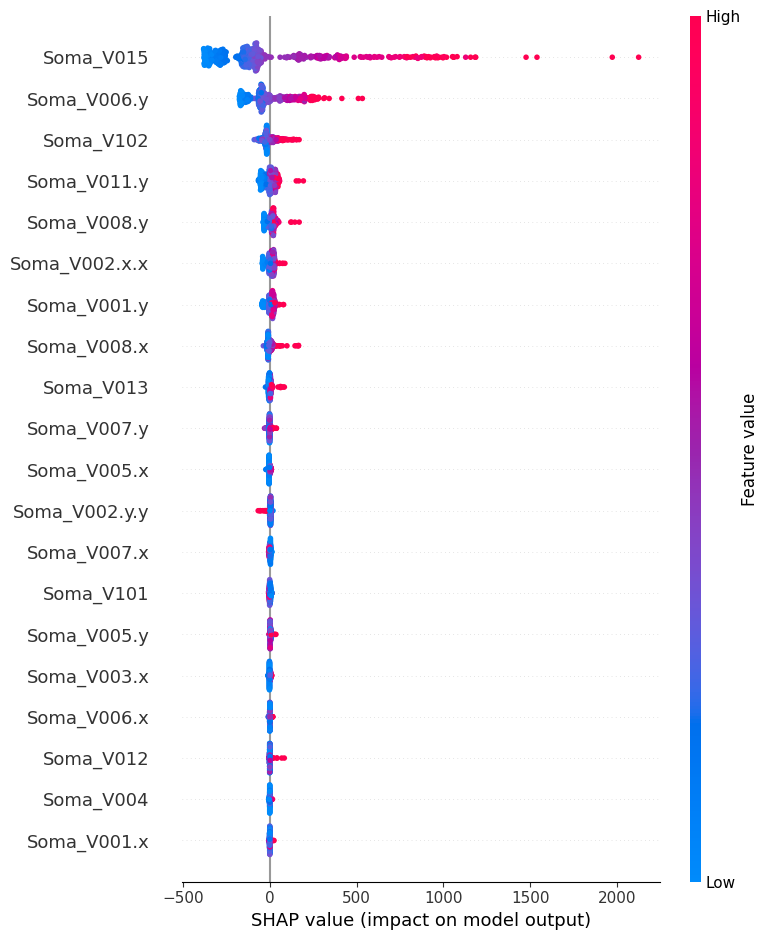

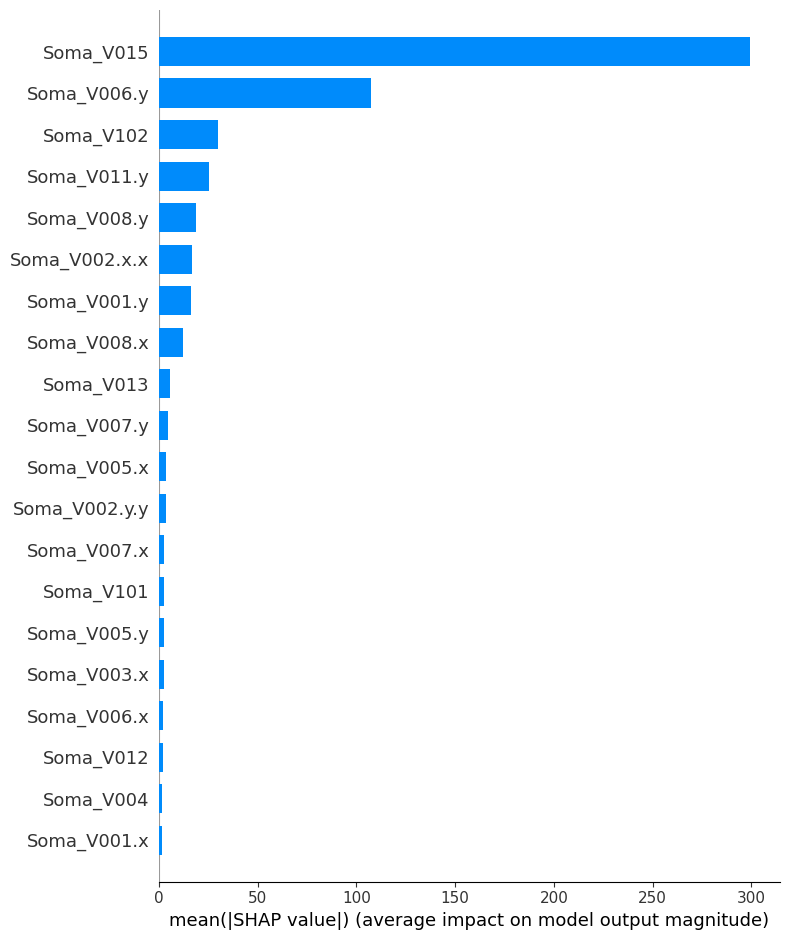

In [ ]:
# =====================================================
# SHAP VALUES
# =====================================================

import shap

print("\nCalculando SHAP...")

explainer = shap.TreeExplainer(modelo_rf)

amostra = X.sample(
    min(500, len(X)),
    random_state=42
)

shap_values = explainer.shap_values(amostra)

# Beeswarm
shap.summary_plot(
    shap_values,
    amostra,
    show=True
)

# Ranking médio
shap.summary_plot(
    shap_values,
    amostra,
    plot_type="bar",
    show=True
)

# **Permutation Importance**


===== TOP 20 VARIÁVEIS =====
               Variavel  Importancia
39            Soma_V015     0.503959
30          Soma_V006.y     0.074671
9             Soma_V102     0.021443
13          Soma_V008.x     0.009770
35          Soma_V011.y     0.008738
32          Soma_V008.y     0.005142
20          Soma_V001.y     0.004368
26        Soma_V002.x.x     0.003354
37            Soma_V013     0.002454
31          Soma_V007.y     0.001894
43        Soma_V002.y.y     0.001340
24          Soma_V005.x     0.000955
22          Soma_V003.x     0.000771
12          Soma_V007.x     0.000698
8             Soma_V101     0.000609
36            Soma_V012     0.000605
65  Soma_soma_V202eV203     0.000516
46            Soma_V011     0.000496
6           Soma_V041.x     0.000448
29          Soma_V005.y     0.000439


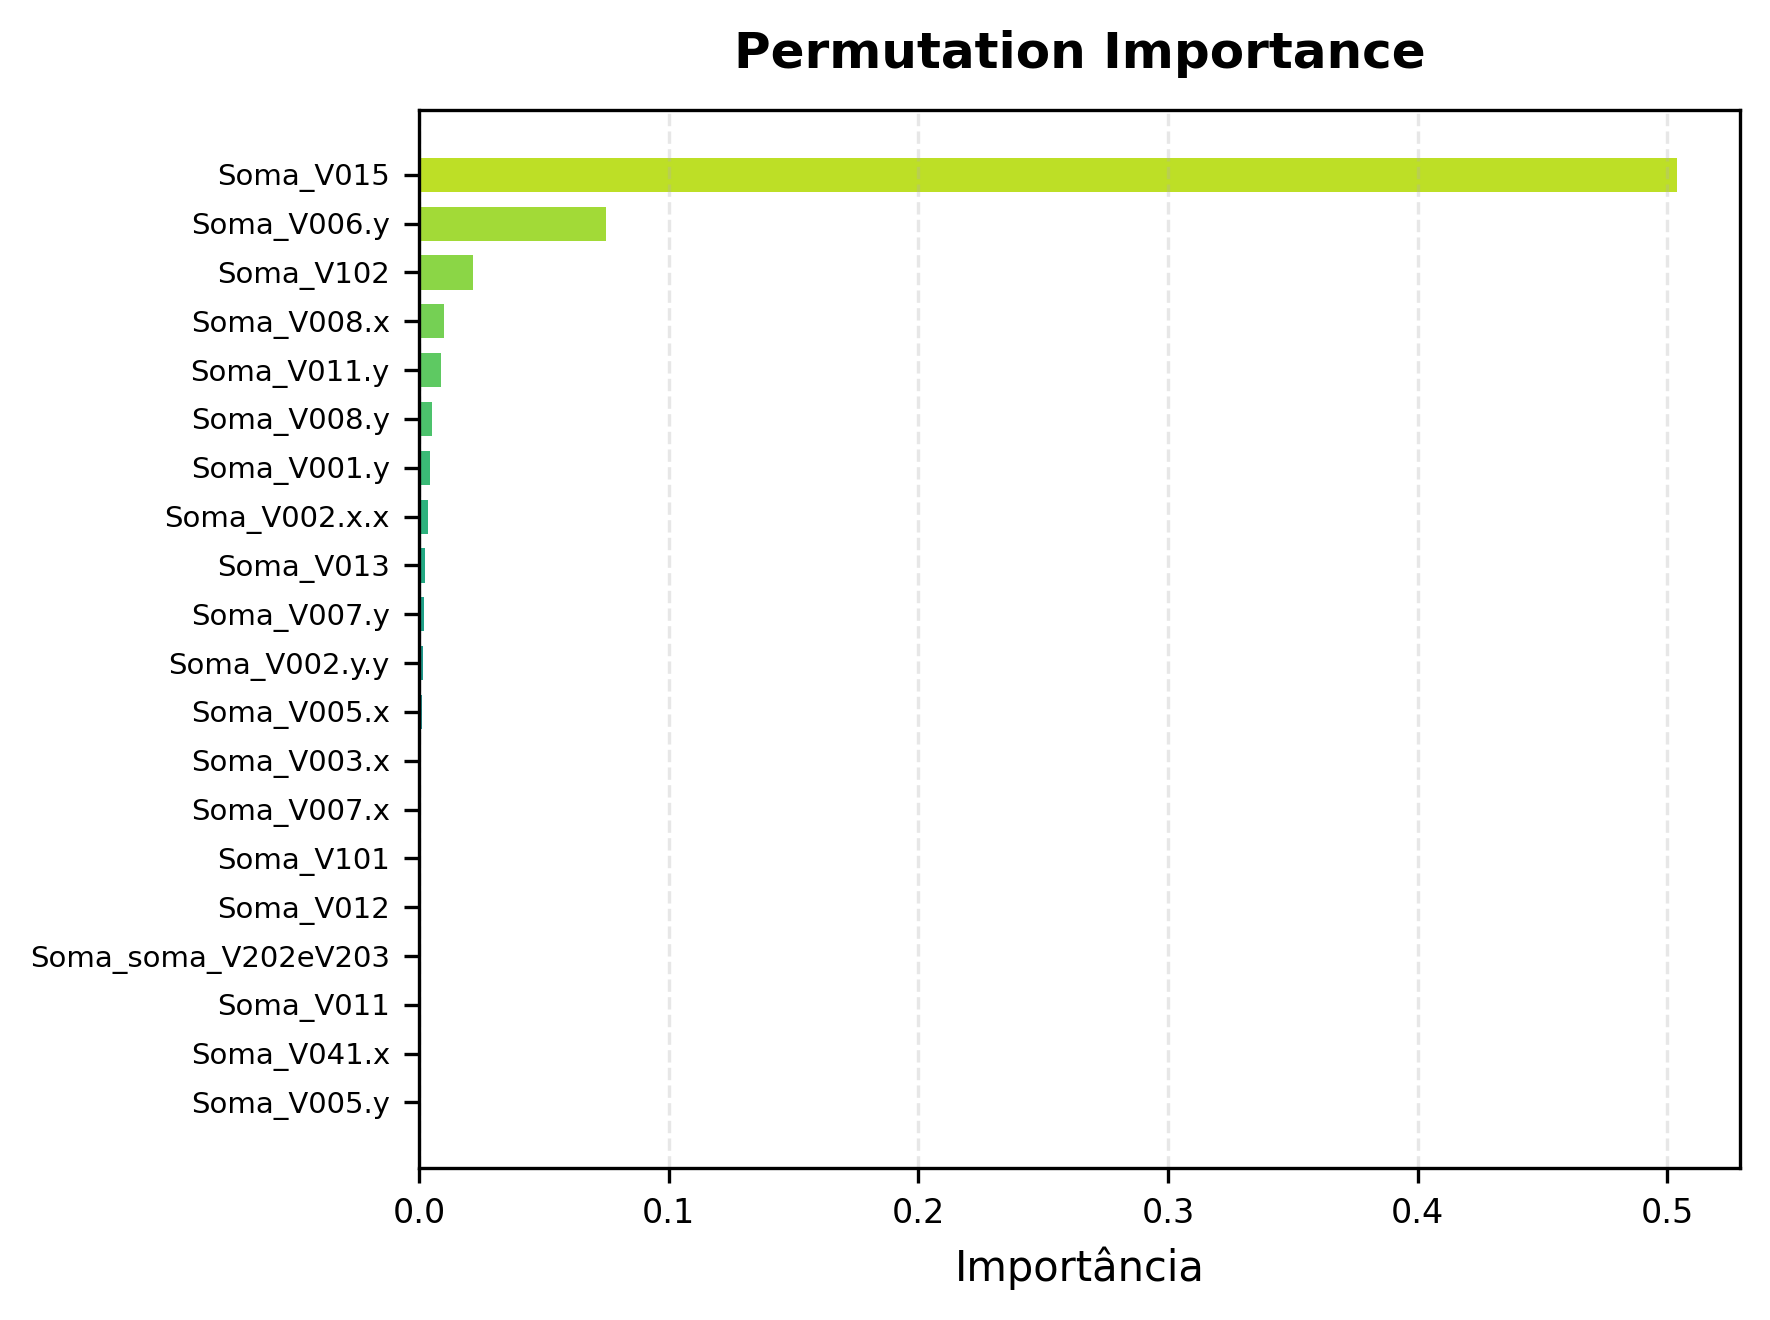

In [ ]:
# =====================================================
# PERMUTATION IMPORTANCE
# =====================================================

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

perm = permutation_importance(
    modelo_rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2"
)

perm_df = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": perm.importances_mean
})

perm_df = perm_df.sort_values(
    "Importancia",
    ascending=False
)

# Exibe as 20 variáveis mais importantes
print("\n===== TOP 20 VARIÁVEIS =====")
print(perm_df.head(20))

# Dados para o gráfico
top = perm_df.head(20).sort_values("Importancia")

# Paleta viridis
cores = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(top))
)

plt.figure(
    figsize=(6, 4.5),
    dpi=300
)

plt.barh(
    top["Variavel"],
    top["Importancia"],
    color=cores,
    height=0.7
)

plt.title(
    "Permutation Importance",
    fontsize=12,
    fontweight="bold",
    pad=10
)

plt.xlabel(
    "Importância",
    fontsize=10
)

plt.xticks(fontsize=8)
plt.yticks(fontsize=7)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# Salvar em JPG
plt.savefig(
    "Permutation_importance.jpg",
    dpi=300,              # qualidade da imagem
    bbox_inches="tight"   # evita cortes nas bordas
)

plt.show()

---
Após o treinamento, o modelo é aplicado a todas as Áreas de Ponderação, incluindo aquelas com valores faltantes. Nesses casos, os valores preditos são utilizados para completar a informação.

Além disso, é criada uma variável indicadora da origem do dado (real ou predito), permitindo rastreabilidade e análise da confiabilidade dos resultados.

In [ ]:
# Predição para TODAS as APs
df_sp_ap["PRED_AP"] = modelo_rf.predict(df_sp_ap[FEATURES])

# Coluna final
# COL_TARGET = DEFICIT_TOTAL
df_sp_ap["DEFICIT_TOTAL_FINAL"] = df_sp_ap["DEFICIT_TOTAL"]

mask_faltante = df_sp_ap["DEFICIT_TOTAL_FINAL"].isna()

df_sp_ap.loc[mask_faltante, "DEFICIT_TOTAL_FINAL"] = df_sp_ap.loc[
    mask_faltante, "PRED_AP"
]

# Fonte
df_sp_ap["FONTE_DEFICIT"] = "real"
df_sp_ap.loc[mask_faltante, "FONTE_DEFICIT"] = "predito"

# Resíduo (diagnóstico)
# COL_TARGET = DEFICIT_TOTAL
df_sp_ap["RESIDUO_AP"] = np.abs(
    df_sp_ap["DEFICIT_TOTAL"] - df_sp_ap["PRED_AP"]
)

# Padronização dos nomes das variáveis
Nesta etapa, é realizado um extenso processo de padronização dos nomes das variáveis do banco de setores censitários.

Essa harmonização é fundamental para garantir compatibilidade com o modelo treinado, já que algoritmos de machine learning exigem consistência entre as variáveis de entrada utilizadas no treinamento e na predição.

In [ ]:
df_sc = df_sp_sc.rename(columns={

    "Domicílios particulares permanentes (=DPP)": "Soma_V002.x",

    # banheiro SC E DPS AP
    "Domicílios particulares permanentes sem banheiro de uso exclusivo dos moradores e nem sanitário":
    "Soma_V023.x",
    # lixo
    "Domicílios particulares permanentes com lixo coletado em caçamba de serviço de limpeza":
    "Soma_V037",

    "Domicílios particulares permanentes com lixo queimado na propriedade":
    "Soma_V038",

    "Domicílios particulares permanentes com lixo enterrado na propriedade":
    "Soma_V039",

    "Domicílios particulares permanentes com lixo jogado em terreno baldio oulogradouro":
    "Soma_V040",

    "Domicílios particulares permanentes com lixo jogado em rio, lago ou mar":
    "Soma_V041.x",

    # energia
    "Domicílios particulares permanentes sem energia elétrica":
    "Soma_V046",

    # tipo de casa
    "Domicílios particulares permanentes do tipo casa próprios e em aquisição":
    "Soma_V101",

    "Domicílios particulares permanentes do tipo casa alugados":
    "Soma_V102",

    "Domicílios particulares permanentes do tipo casa cedidos por empregador":
    "Soma_V103",

    "Domicílios particulares permanentes com outra forma de destino do lixo e outra forma de abastecimento de água":
    "Soma_V233",

    # moradores
    "Moradores em domicílios particulares permanentes próprios e em aquisição":
    "Soma_V007.x",

    "Moradores em domicílios particulares permanentes alugados":
    "Soma_V008.x",

    "Moradores em domicílios particulares permanentes cedidos por empregador":
    "Soma_V009.x",

    "Moradores em domicílios particulares permanentes com outra condição de ocupação (não são próprios, alugados, nem cedidos)":
    "Soma_V011.x",

    "Moradores em domicílios particulares permanentes sem banheiro de uso exclusivo dos moradores e nem sanitário":
    "Soma_V023.y",

    "Moradores em domicílios particulares permanentes sem energia elétrica":
    "Soma_V041.y",

    # Pessoas
    "Pessoas responsáveis, do sexo feminino": "Soma_V001.x",
    "Pessoas responsáveis, do sexo masculino": "Soma_V109",

    "Pessoas Residentes":"Soma_V001.y",
    "Pessoas Residentes e cor ou raça - branca":"Soma_V002.y",
    "Pessoas Residentes e cor ou raça - preta":"Soma_V003.x",
    "Pessoas Residentes e cor ou raça - amarela":"Soma_V004.x",
    "Pessoas Residentes e cor ou raça - parda":"Soma_V005.x",
    "Pessoas Residentes e cor ou raça - indígena":"Soma_V006.x",
    "Pessoas residentes em domicílios particulares permanentes":"Soma_V002.x.x",


    "Responsáveis pelos domicílios particulares": "Soma_V003.y",


    "Cônjuges ou companheiros(as) (de sexo diferente e do mesmo sexo da pessoa responsável) em domicílios particulares": "Soma_V004.y",
    "Filhos(as) do responsável e do cônjuge em domicílios particulares": "Soma_V005.y",
    "Filhos(as) somente do responsável em domicílios particulares": "Soma_V006.y",
    "Enteados(as) em domicílios particulares": "Soma_V007.y",
    "Genros ou noras em domicílios particulares": "Soma_V008.y",
    "Pais, mães, padrastos ou madrastas em domicílios particulares": "Soma_V009.y",
    "Sogros (as) em domicílios particulares": "Soma_V010",
    "Netos(as) em domicílios particulares": "Soma_V011.y",
    "Bisnetos(as) em domicílios particulares": "Soma_V012",
    "Irmãos ou irmãs em domicílios particulares": "Soma_V013",
    "Avôs ou avós em domicílios particulares": "Soma_V014.x",
    "Outros parentes em domicílios particulares": "Soma_V015",
    "Agregados(as) em domicílios particulares": "Soma_V016",
    "Conviventes em domicílios particulares": "Soma_V017.x",

    "Total de domicílios particulares improvisados": "Soma_V001",
    "Total do rendimento nominal mensal dos domicílios particulares": "Soma_V002.y.y",
    "Total do rendimento nominal mensal dos domicílios particulares improvisados": "Soma_V004",

    "Domicílios particulares sem rendimento nominal mensal domiciliar per capita": "Soma_V014.y",
    "Domicílios particulares permanentes alugados – Não existe iluminação pública": "Soma_V011",
    "Domicílios particulares permanentes alugados – Não existe pavimentação": "Soma_V017.y",
    "Domicílios particulares permanentes próprios – Existe esgoto a céu aberto": "Soma_V050",
    "Domicílios particulares permanentes alugados – Existe esgoto a céu aberto": "Soma_V052",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe iluminação pública":
    "Soma_V113",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe pavimentação":
    "Soma_V119",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe calçada":
    "Soma_V125",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe meio-fio/guia":
    "Soma_V131",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe bueiro/boca-de-lobo":
    "Soma_V137",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe rampa para cadeirante":
    "Soma_V143",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe arborização":
    "Soma_V149",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Existe esgoto a céu aberto":
    "Soma_V154",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Existe lixo acumulado nos logradouros":
    "Soma_V160",

    "Domicílios particulares permanentes com moradia adequada – Existe identificação do logradouro":
    "Soma_V202",

    "Domicílios particulares permanentes com moradia adequada – Não existe identificação do logradouro":
    "Soma_V203",
    "Domicílios particulares permanentes com moradia semi-adequada – Existe identificação do logradouro": "Soma_V204",
    "Domicílios particulares permanentes com moradia semi-adequada – Não existe identificação do logradouro": "Soma_V205",
    "Domicílios particulares permanentes com moradia inadequada –  Existe identificação do logradouro": "Soma_V206",
    "Domicílios particulares permanentes com moradia inadequada – Não existe identificação do logradouro": "Soma_V207",

    "soma_V202eV203": "Soma_soma_V202eV203",
    "soma_V204eV205": "Soma_soma_V204eV205",
    "soma_V206eV207": "Soma_soma_V206eV207"


})

O modelo treinado nas Áreas de Ponderação é aplicado diretamente aos setores censitários, gerando uma predição bruta para cada setor.

Esses valores não representam ainda o déficit final, mas sim uma medida relativa da propensão de cada setor em apresentar déficit habitacional.

In [ ]:
df_sc["PRED_SC_BRUTO"] = modelo_rf.predict(df_sc[FEATURES])

Nesta etapa, é feita a verificação da consistência entre os conjuntos de variáveis utilizados nos dois bancos de dados.

Essa checagem é importante para evitar erros de execução e garantir que o modelo esteja recebendo exatamente as mesmas variáveis que foram utilizadas durante o treinamento.

In [ ]:
df_sp_ap.columns


Index(['AREA_POND', 'Cod_UF', 'Nome_da_UF', 'Cod_meso', 'Nome_da_meso',
       'Cod_micro', 'Nome_da_micro', 'Cod_RM', 'Nome_da_RM', 'Cod_municipio',
       'Nome_do_municipio', 'Soma_V002.x', 'Soma_V023.x', 'Soma_V037',
       'Soma_V038', 'Soma_V039', 'Soma_V040', 'Soma_V041.x', 'Soma_V046',
       'Soma_V101', 'Soma_V102', 'Soma_V103', 'Soma_V233', 'Soma_V007.x',
       'Soma_V008.x', 'Soma_V009.x', 'Soma_V011.x', 'Soma_V023.y',
       'Soma_V041.y', 'Soma_V001.x', 'Soma_V109', 'Soma_V001.y', 'Soma_V002.y',
       'Soma_V003.x', 'Soma_V004.x', 'Soma_V005.x', 'Soma_V006.x',
       'Soma_V002.x.x', 'Soma_V003.y', 'Soma_V004.y', 'Soma_V005.y',
       'Soma_V006.y', 'Soma_V007.y', 'Soma_V008.y', 'Soma_V009.y', 'Soma_V010',
       'Soma_V011.y', 'Soma_V012', 'Soma_V013', 'Soma_V014.x', 'Soma_V015',
       'Soma_V016', 'Soma_V017.x', 'Soma_V001', 'Soma_V002.y.y', 'Soma_V004',
       'Soma_V014.y', 'Soma_V011', 'Soma_V017.y', 'Soma_V050', 'Soma_V052',
       'Soma_V113', 'Soma_V119', 'Soma

In [ ]:
df_sc.columns


Index(['Cod_setor', 'Cod_Grandes_Regiões', 'Nome_Grande_Regiao', 'Cod_UF',
       'Nome_da_UF', 'Cod_meso', 'Nome_da_meso', 'Cod_micro', 'Nome_da_micro',
       'Cod_RM', 'Nome_da_RM', 'Cod_municipio', 'Nome_do_municipio',
       'Situacao_setor', 'Área de Ponderação', 'Soma_V002.x', 'Soma_V023.x',
       'Soma_V037', 'Soma_V038', 'Soma_V039', 'Soma_V040', 'Soma_V041.x',
       'Soma_V046', 'Soma_V101', 'Soma_V102', 'Soma_V103', 'Soma_V233',
       'Soma_V007.x', 'Soma_V008.x', 'Soma_V009.x', 'Soma_V011.x',
       'Soma_V023.y', 'Soma_V041.y', 'Soma_V001.x', 'Soma_V109', 'Soma_V001.y',
       'Soma_V002.y', 'Soma_V003.x', 'Soma_V004.x', 'Soma_V005.x',
       'Soma_V006.x', 'Soma_V002.x.x', 'Soma_V003.y', 'Soma_V004.y',
       'Soma_V005.y', 'Soma_V006.y', 'Soma_V007.y', 'Soma_V008.y',
       'Soma_V009.y', 'Soma_V010', 'Soma_V011.y', 'Soma_V012', 'Soma_V013',
       'Soma_V014.x', 'Soma_V015', 'Soma_V016', 'Soma_V017.x', 'Soma_V001',
       'Soma_V002.y.y', 'Soma_V004', 'Soma_V014.y', 

# **PROCESSO DE PROPENSÃO**

Para cada Área de Ponderação, os setores censitários correspondentes são agrupados. Em seguida, utiliza-se a soma das predições do modelo (propensões) para calcular a participação relativa de cada setor dentro da área.

Matematicamente, cada setor recebe um peso proporcional à sua predição em relação à soma total das predições da sua AP. Esse peso é então utilizado para distribuir o déficit total da área entre os setores.

Esse método é conhecido como abordagem de alocação proporcional baseada em escores de propensão e permite transformar um problema de agregação em uma estimativa espacialmente detalhada, mantendo coerência estatística.

In [ ]:
resultados = []

for cod_ap, grupo_sc in df_sc.groupby(COL_AP_SC):

    linha_ap = df_sp_ap[df_sp_ap[COL_AP_AP] == cod_ap]

    if linha_ap.empty:
        continue

    linha_ap = linha_ap.iloc[0]

    valor_base = linha_ap["DEFICIT_TOTAL_FINAL"]
    fonte = linha_ap["FONTE_DEFICIT"]
    residuo = linha_ap["RESIDUO_AP"]

    soma_pred = grupo_sc["PRED_SC_BRUTO"].sum()

    for _, row in grupo_sc.iterrows():

        if soma_pred > 0:
            peso = row["PRED_SC_BRUTO"] / soma_pred
            deficit_sc = valor_base * peso
        else:
            peso = 0
            deficit_sc = 0

        resultados.append({
            "COD_SC": row[COL_SC],
            "COD_AP": cod_ap,
            "DEFICIT_TOTAL_PROPENSO": deficit_sc,
            "PESO": peso,
            "FONTE_VALOR_AP": fonte,
            "RESIDUO_AP": residuo
        })

In [ ]:
df_resultado = (
    pd.DataFrame(resultados)
    .sort_values(["COD_AP", "COD_SC"])
    .reset_index(drop=True)
)

print(df_resultado.head())

            COD_SC         COD_AP  DEFICIT_TOTAL_PROPENSO      PESO  \
0  350010505000009  3500105003001               16.172729  0.041048   
1  350010505000010  3500105003001               18.892467  0.047950   
2  350010505000011  3500105003001               25.621170  0.065028   
3  350010505000012  3500105003001               17.625317  0.044734   
4  350010505000013  3500105003001               14.883503  0.037775   

  FONTE_VALOR_AP  RESIDUO_AP  
0           real      13.915  
1           real      13.915  
2           real      13.915  
3           real      13.915  
4           real      13.915  


A análise dos resultados mostra que o processo de desagregação foi realizado com sucesso, permitindo obter estimativas em nível de setor censitário.

Além disso, a estrutura dos dados resultantes possibilita análises detalhadas e aplicações práticas, como identificação de áreas prioritárias.

In [ ]:
auditoria = (
    df_resultado
    .groupby("COD_AP", as_index=False)
    .agg(SOMA_SC=("DEFICIT_TOTAL_PROPENSO", "sum"))
    .merge(
        df_sp_ap[[COL_AP_AP, "DEFICIT_TOTAL_FINAL"]],
        left_on="COD_AP",
        right_on=COL_AP_AP,
        how="left"
    )
)

auditoria["DIFERENCA"] = auditoria["SOMA_SC"] - auditoria["DEFICIT_TOTAL_FINAL"]
auditoria["DIF_ABS"] = auditoria["DIFERENCA"].abs()

print(auditoria.sort_values("DIF_ABS", ascending=False).head())

             COD_AP  SOMA_SC      AREA_POND  DEFICIT_TOTAL_FINAL  \
1274  3548500005007   4401.0  3548500005007                 4401   
1407  3550308005033   2787.0  3550308005033                 2787   
547   3518800005027   2753.0  3518800005027                 2753   
1744  3552205005019   1173.0  3552205005019                 1173   
510   3518701005005   1315.0  3518701005005                 1315   

         DIFERENCA       DIF_ABS  
1274  9.094947e-13  9.094947e-13  
1407 -9.094947e-13  9.094947e-13  
547   4.547474e-13  4.547474e-13  
1744  4.547474e-13  4.547474e-13  
510  -4.547474e-13  4.547474e-13  


A verificação das colunas do banco final garante que todas as informações relevantes foram corretamente incorporadas, permitindo análises posteriores de forma consistente e confiável.

In [ ]:
print(df_resultado.columns)

Index(['COD_SC', 'COD_AP', 'DEFICIT_TOTAL_PROPENSO', 'PESO', 'FONTE_VALOR_AP',
       'RESIDUO_AP'],
      dtype='object')


Os resultados evidenciam que o método adotado foi eficaz na preservação dos totais agregados, ao mesmo tempo em que permitiu a identificação de setores com maior concentração de déficit habitacional.

Isso demonstra a capacidade do modelo em capturar padrões espaciais relevantes.


# **correlacao**

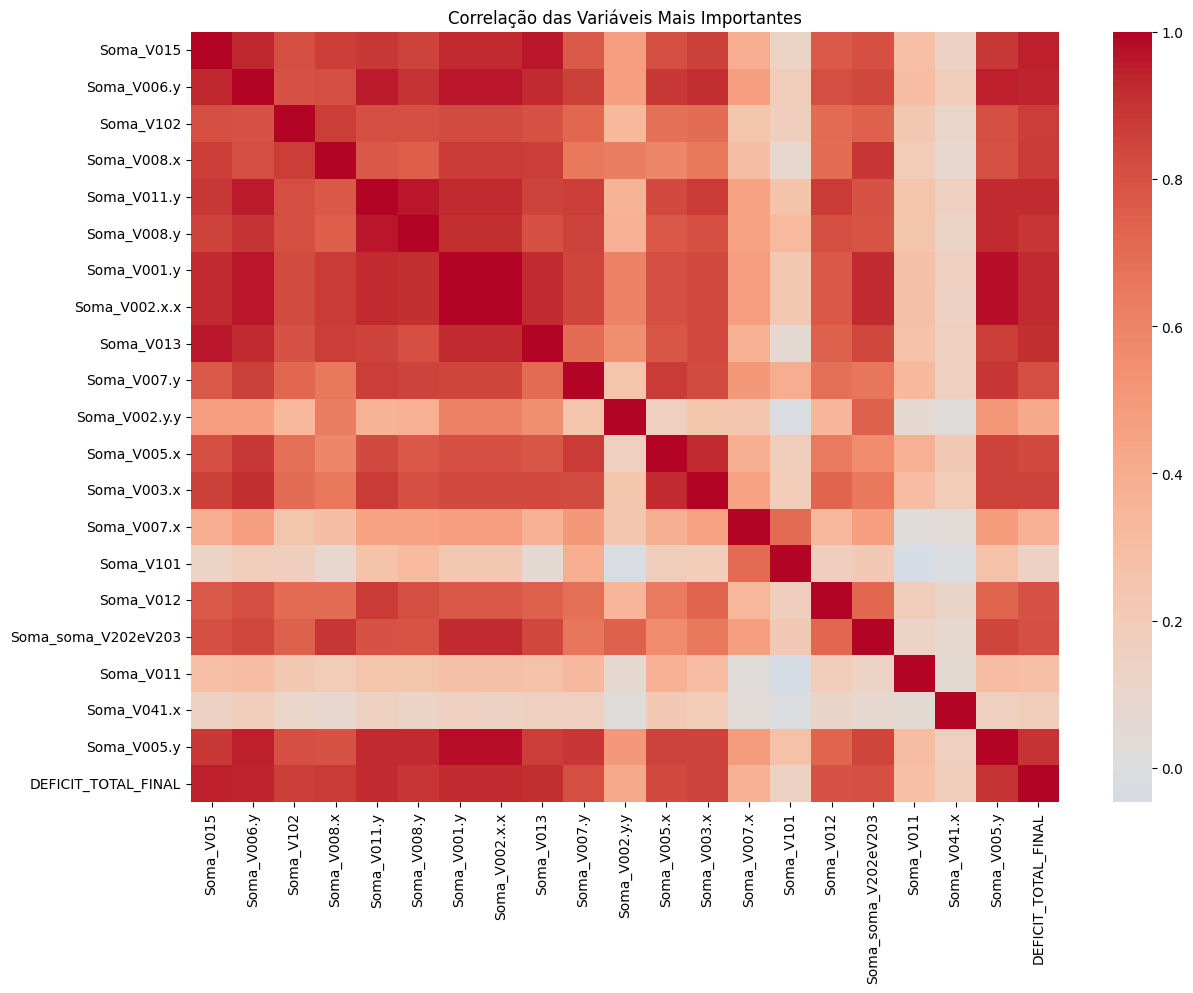

In [ ]:
# =====================================================
# MATRIZ DE CORRELAÇÃO
# =====================================================
import seaborn as sns
import matplotlib.pyplot as plt
top_vars = perm_df.head(20)["Variavel"].tolist()

corr = df_sp_ap[
    top_vars + ["DEFICIT_TOTAL_FINAL"]
].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlação das Variáveis Mais Importantes")


# Salvar em JPG
plt.savefig(
    "matriz_correlacao.jpg",
    dpi=300,              # qualidade da imagem
    bbox_inches="tight"   # evita cortes nas bordas
)

plt.show()

In [ ]:
import geopandas as gpd

gdf = gpd.read_file(
    "SP_setores_CD2022.zip"
)
print(gdf.head())

          CD_SETOR SITUACAO CD_SIT CD_TIPO  AREA_KM2 CD_REGIAO NM_REGIAO  \
0  350010505000001   Urbana      1       0  0.123824         3   Sudeste   
1  350010505000002   Urbana      1       0  0.202614         3   Sudeste   
2  350010505000003   Urbana      1       0  0.235048         3   Sudeste   
3  350010505000004   Urbana      1       0  0.288468         3   Sudeste   
4  350010505000005   Urbana      1       0  0.213724         3   Sudeste   

  CD_UF      NM_UF   CD_MUN  ... NM_FCU CD_AGLOM NM_AGLOM CD_RGINT  \
0    35  São Paulo  3500105  ...   None     None     None     3505   
1    35  São Paulo  3500105  ...   None     None     None     3505   
2    35  São Paulo  3500105  ...   None     None     None     3505   
3    35  São Paulo  3500105  ...   None     None     None     3505   
4    35  São Paulo  3500105  ...   None     None     None     3505   

              NM_RGINT  CD_RGI                NM_RGI CD_CONCURB NM_CONCURB  \
0  Presidente Prudente  350019  Adamantina -

In [ ]:
print(df_resultado.columns)

Index(['COD_SC', 'COD_AP', 'DEFICIT_TOTAL_PROPENSO', 'PESO', 'FONTE_VALOR_AP',
       'RESIDUO_AP'],
      dtype='object')


In [ ]:
# =====================================================
# JUNÇÃO DOS RESULTADOS COM A MALHA DOS SETORES
# =====================================================

import geopandas as gpd

gdf["CD_SETOR"] = gdf["CD_SETOR"].astype(str)
df_resultado["COD_SC"] = df_resultado["COD_SC"].astype(str)

gdf_deficit = gdf.merge(
    df_resultado,
    left_on="CD_SETOR",
    right_on="COD_SC",
    how="inner"
)

print("Setores com geometria:", len(gdf_deficit))

Setores com geometria: 38234


In [ ]:
!pip install esda libpysal

# **MORAN GLOBAL**

In [ ]:
# =================
# MORAN GLOBAL
# =================

import pandas as pd
from IPython.display import display
from libpysal.weights import KNN
from esda.moran import Moran

# K = 8 vizinhos
w = KNN.from_dataframe(
    gdf_deficit,
    k=8
)

w.transform = "R"

# Cálculo do Moran Global
mi = Moran(
    gdf_deficit["DEFICIT_TOTAL_PROPENSO"],
    w,
    permutations=999
)

# ==========================
# Tabela de resultados
# ==========================

resultado_moran = pd.DataFrame({
    "Estatística": [
        "Moran I",
        "p-valor",
        "Número de permutações",
        "Tipo de vizinhança"
    ],
    "Resultado": [
        round(mi.I, 6),
        round(mi.p_sim, 6),
        999,
        "KNN (k=8)"
    ]
})

display(resultado_moran)

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 115 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


,Estatística,Resultado
0,Moran I,0.524625
1,p-valor,0.001
2,Número de permutações,999
3,Tipo de vizinhança,KNN (k=8)


# **MORAN LOCAL (LISA)**

In [ ]:
# =====================================================
# LISA (LOCAL MORAN)
# =====================================================

import pandas as pd
from IPython.display import display
from esda.moran import Moran_Local

lisa = Moran_Local(
    gdf_deficit["DEFICIT_TOTAL_PROPENSO"],
    w,
    permutations=999
)

gdf_deficit["LISA_P"] = lisa.p_sim
gdf_deficit["LISA_Q"] = lisa.q

gdf_deficit["SIGNIFICATIVO"] = (
    gdf_deficit["LISA_P"] < 0.05
)

display(
    gdf_deficit[
        ["LISA_Q", "SIGNIFICATIVO"]
    ].head()
)

,LISA_Q,SIGNIFICATIVO
0,3,True
1,3,True
2,3,False
3,4,False
4,4,False


# **Classificação HH LL HL LH**

In [ ]:
# =====================================================
# CLASSIFICAÇÃO LISA
# =====================================================

import pandas as pd
from IPython.display import display

def classifica_lisa(row):

    if not row["SIGNIFICATIVO"]:
        return "Nao significativo"

    if row["LISA_Q"] == 1:
        return "HH"

    elif row["LISA_Q"] == 2:
        return "LH"

    elif row["LISA_Q"] == 3:
        return "LL"

    elif row["LISA_Q"] == 4:
        return "HL"

    return "Nao significativo"


gdf_deficit["CLUSTER"] = (
    gdf_deficit.apply(
        classifica_lisa,
        axis=1
    )
)

# =====================================================
# Tabela de resultados
# =====================================================

resultado_clusters = (
    gdf_deficit["CLUSTER"]
    .value_counts()
    .reset_index()
)

resultado_clusters.columns = [
    "Cluster LISA",
    "Quantidade"
]

display(resultado_clusters)

,Cluster LISA,Quantidade
0,Nao significativo,21891
1,LL,8738
2,HH,5948
3,LH,1285
4,HL,372


# **MAPA LISA**

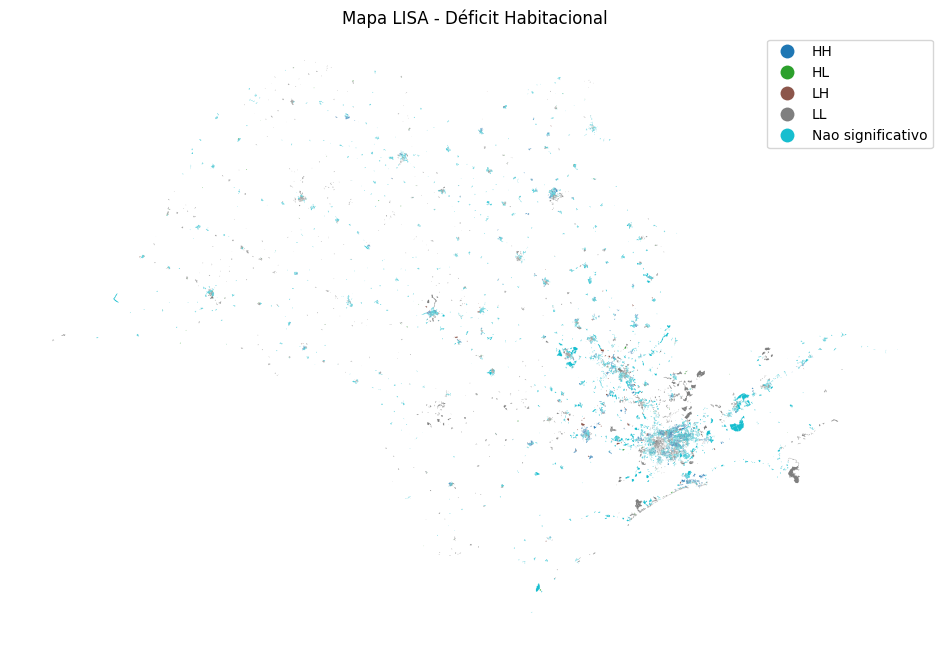

In [ ]:
# =====================================================
# MAPA LISA
# =====================================================

fig, ax = plt.subplots(
    figsize=(12,12)
)

gdf_deficit.plot(
    column="CLUSTER",
    legend=True,
    ax=ax
)

plt.title(
    "Mapa LISA - Déficit Habitacional"
)

plt.axis("off")


# Salvar em JPG
plt.savefig(
    "Mapa_LISA.jpg",
    dpi=300,              # qualidade da imagem
    bbox_inches="tight"   # evita cortes nas bordas
)

plt.show()

# **Moran Scatter Plot**

In [ ]:
!pip install splot

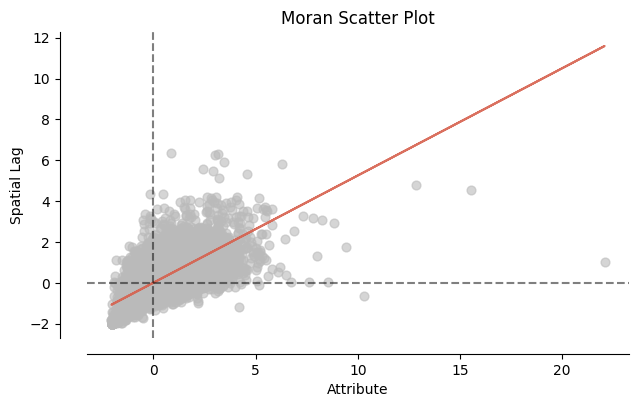

In [ ]:
from esda.moran import Moran
from splot.esda import moran_scatterplot

fig, ax = moran_scatterplot(mi)

plt.title(
    "Moran Scatter Plot"
)

plt.show()

# **Mapa do déficit**

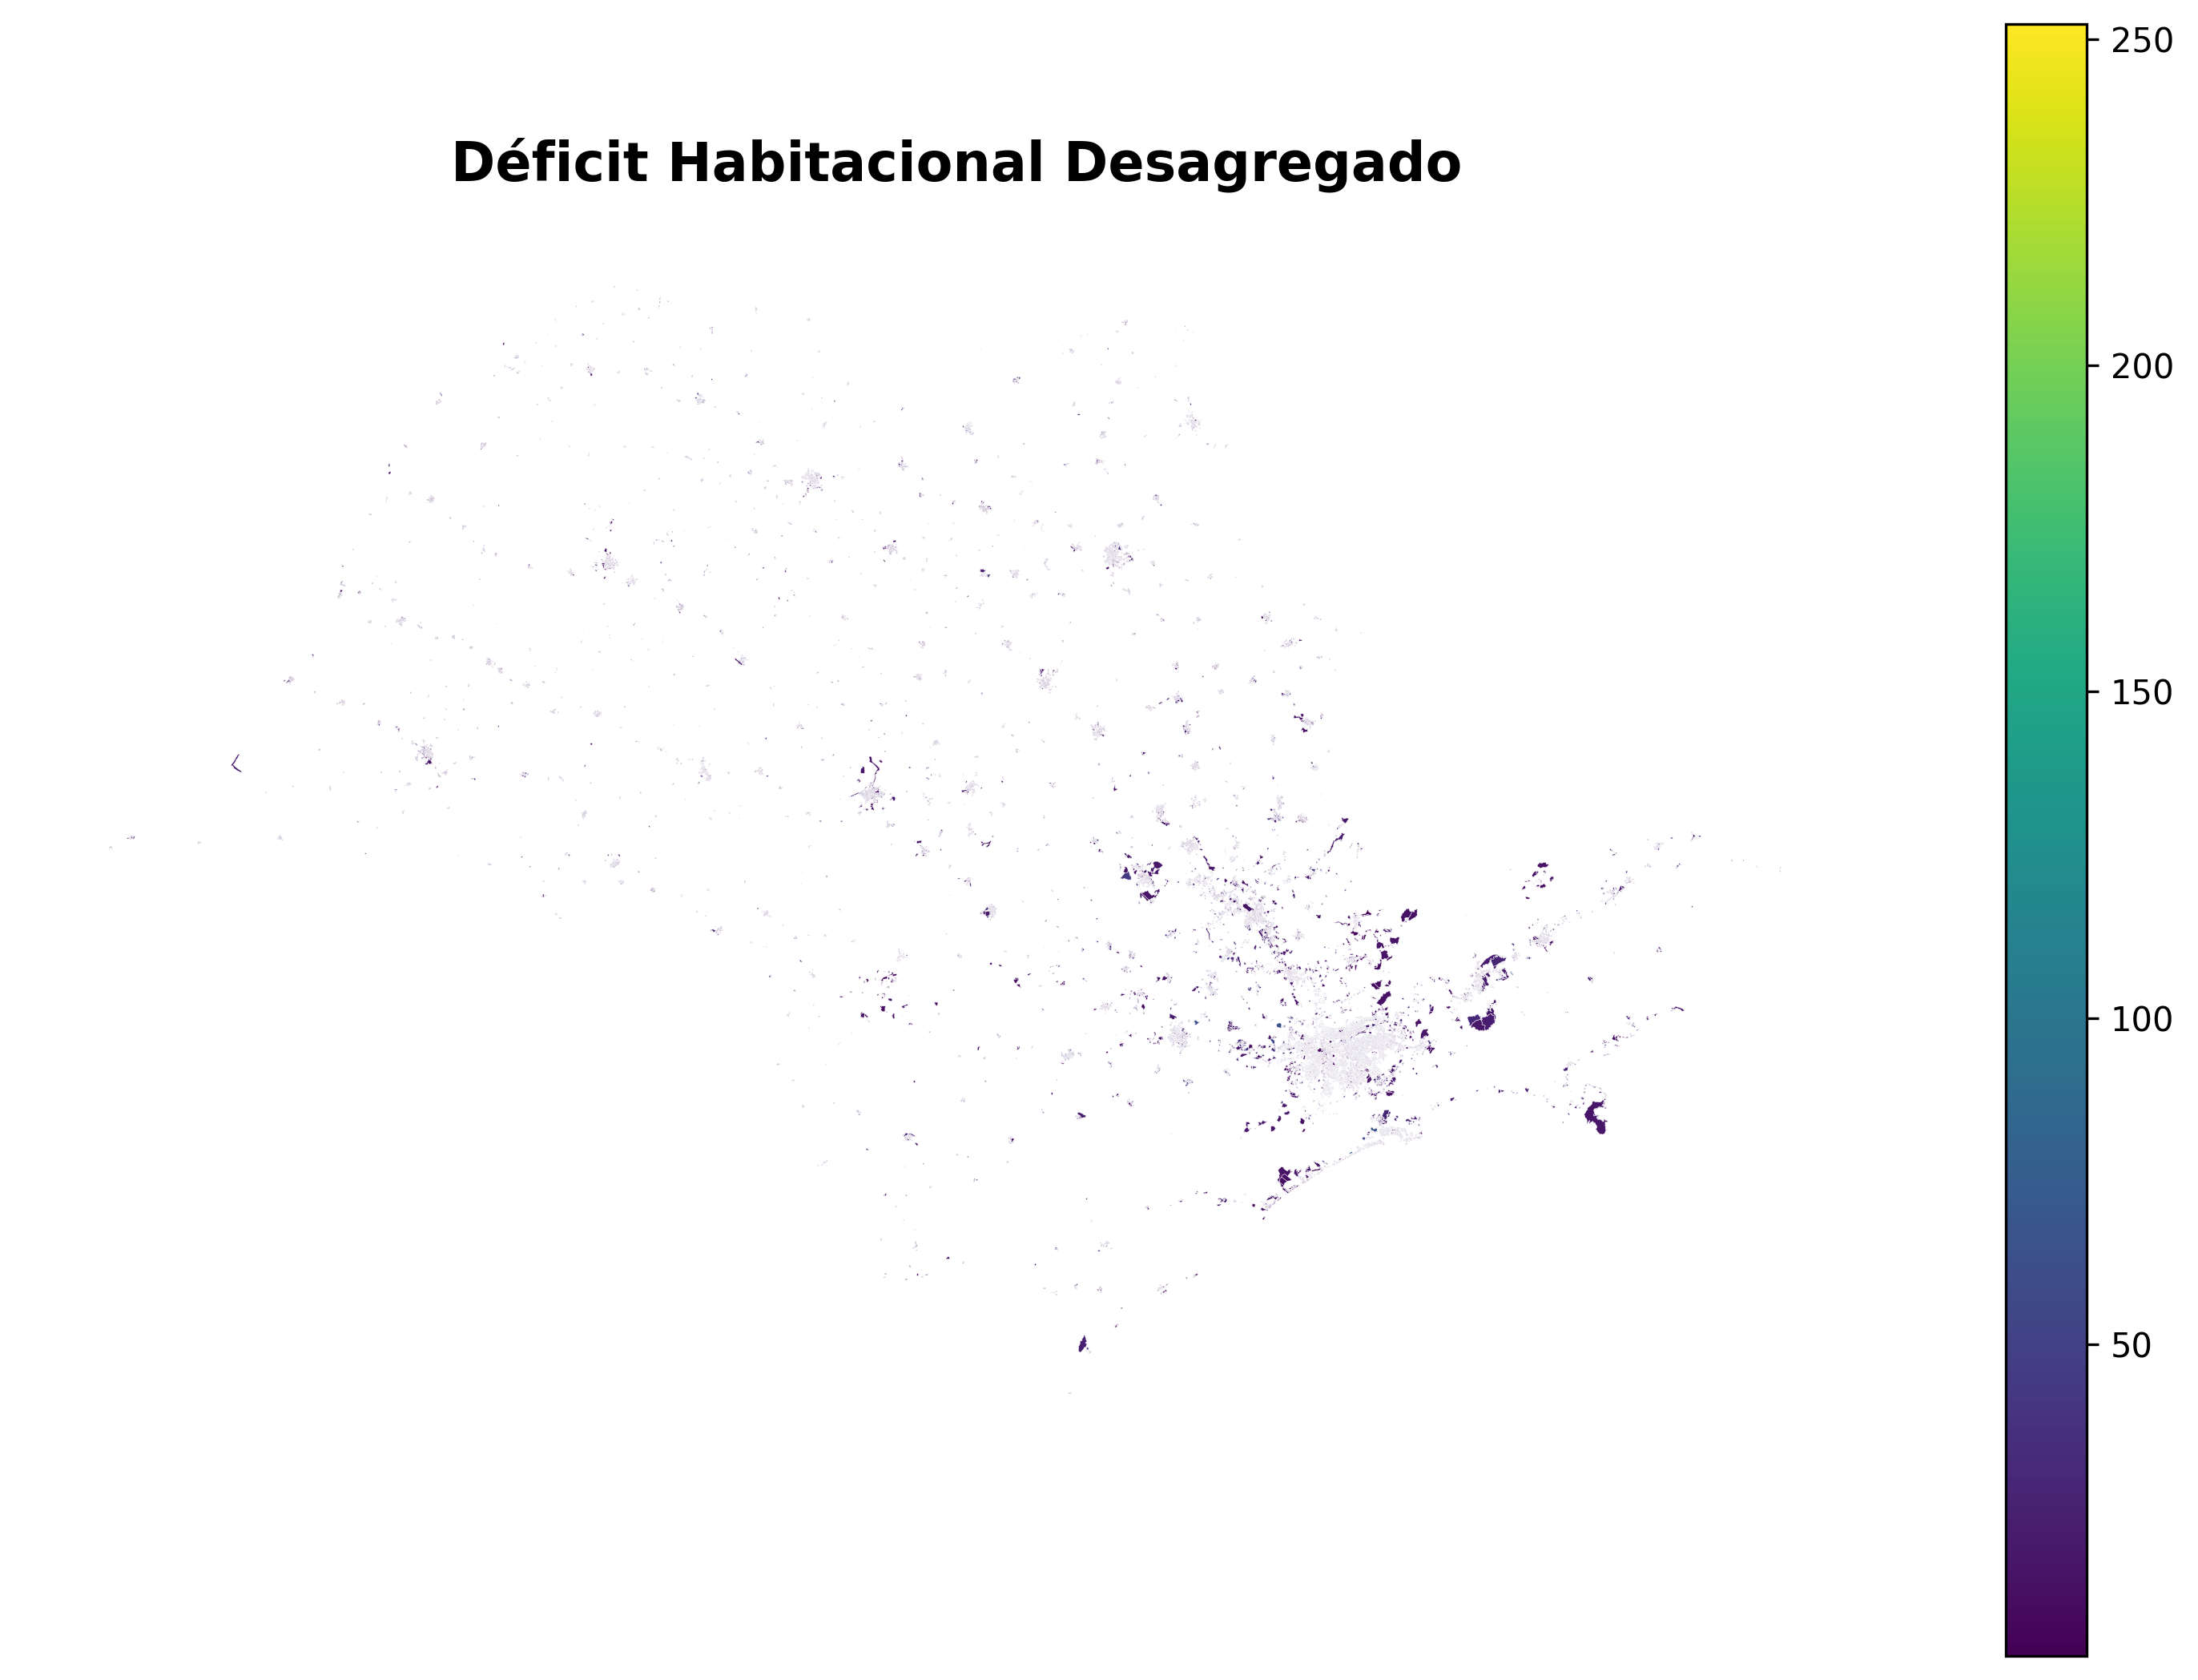

In [ ]:
# =====================================================
# MAPA DO DÉFICIT
# =====================================================

fig, ax = plt.subplots(
    figsize=(10, 10),
    dpi=300
)

gdf_deficit.plot(
    column="DEFICIT_TOTAL_PROPENSO",
    cmap="viridis",      # ou YlOrRd se preferir
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    ax=ax,
    legend_kwds={
        "shrink": 0.7
    }
)

ax.set_title(
    "Déficit Habitacional Desagregado",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.axis("off")

plt.tight_layout()

# Salvar em JPG
plt.savefig(
    "Deficit_Habitacional_Desagregado.jpg",
    dpi=300,              # qualidade da imagem
    bbox_inches="tight"   # evita cortes nas bordas
)


plt.show()